In [1]:
import pandas as pd

qa_path_1 = "/mnt/data/shansong/ADC/ADC/is_final_real/1_data/hard_QA/H_00/Question.jsonl"
qa_path_2 = "/mnt/data/shansong/ADC/ADC/is_final_real/2_data/hard_QA/H_00/Question.jsonl"
qa_path_3 = "/mnt/data/shansong/ADC/ADC/is_final_real/3_data/hard_QA/H_00/Question.jsonl"
qa_path_4 = "/mnt/data/shansong/ADC/ADC/is_final_real/4_data/hard_QA/H_00/Question.jsonl"
qa_path_5 = "/mnt/data/shansong/ADC/ADC/is_final_real/5_data/hard_QA/H_00/Question.jsonl"


qa_df_1 = pd.read_json(qa_path_1, lines=True)
qa_df_2 = pd.read_json(qa_path_2, lines=True)
qa_df_3 = pd.read_json(qa_path_3, lines=True)
qa_df_4 = pd.read_json(qa_path_4, lines=True)
qa_df_5 = pd.read_json(qa_path_5, lines=True)

qa_df_all = pd.concat([qa_df_1, qa_df_2, qa_df_3, qa_df_4, qa_df_5], ignore_index=True)
print(qa_df_all.shape)
print(qa_df_all.columns)

qa_df_all.head(2)

(869, 6)
Index(['question', 'answer', 'evidence_list', 'com_err', 'reason', 'titles'], dtype='object')


,question,answer,evidence_list,com_err,reason,titles
0,Please summarize the paper Quantifying and Mit...,"[label error, group-based disparity metrics, i...","[{'id': 1, 'url': 'https://openreview.net/pdf?...",[],NaN,NaN
1,Please summarize the paper Suppression helps: ...,"[Lateral inhibition mechanism, Deep convolutio...","[{'id': 2, 'url': 'https://openreview.net/pdf?...",[],NaN,NaN


In [2]:
def get_answer_length_for_summary(answer):
    if isinstance(answer, list):
        return len(answer)
    if isinstance(answer, str):
        answer = answer.strip()
        if answer == "[]":
            return 0
        if answer.startswith("[") and answer.endswith("]"):
            inner = answer[1:-1].strip()
            if not inner:
                return 0
            return len([item.strip() for item in inner.split(",") if item.strip()])
    raise TypeError(f"Unsupported answer type: {type(answer).__name__}")

def build_group_distribution_for_summary(lengths, upper_bound=30, zero_count=None, step=2):
    non_zero_lengths = lengths[lengths > 0]
    step = max(int(step), 0)
    length_groups = [(start, min(start + step, upper_bound)) for start in range(1, upper_bound + 1, step + 1)]
    group_labels = ["0"] + [f"{start}-{end}" for start, end in length_groups]
    zero_bucket = int((lengths == 0).sum()) if zero_count is None else int(zero_count)
    group_counts = [zero_bucket] + [non_zero_lengths.between(start, end).sum() if not non_zero_lengths.empty else 0 for start, end in length_groups]
    return group_labels, group_counts

upper_bound = 30
step = 2

answer_lengths_for_summary = qa_df_all["answer"].apply(get_answer_length_for_summary)
hallucination_lengths_for_summary = qa_df_all["com_err"].apply(len)

topic_ranges, answer_topic_counts = build_group_distribution_for_summary(
    answer_lengths_for_summary,
    upper_bound=upper_bound,
    step=step,
)
_, hallucination_topic_counts = build_group_distribution_for_summary(
    hallucination_lengths_for_summary,
    upper_bound=upper_bound,
    step=step,
)

topic_length_summary = pd.DataFrame(
    {
        "Number of topics": topic_ranges,
        "Topics in answer": answer_topic_counts,
        "Topics in hallucination": hallucination_topic_counts,
    }
)

topic_length_summary


,Number of topics,Topics in answer,Topics in hallucination
0,0,0,550
1,1-3,130,168
2,4-6,185,95
3,7-9,68,51
4,10-12,51,5
5,13-15,232,0
6,16-18,194,0
7,19-21,2,0
8,22-24,4,0
9,25-27,2,0


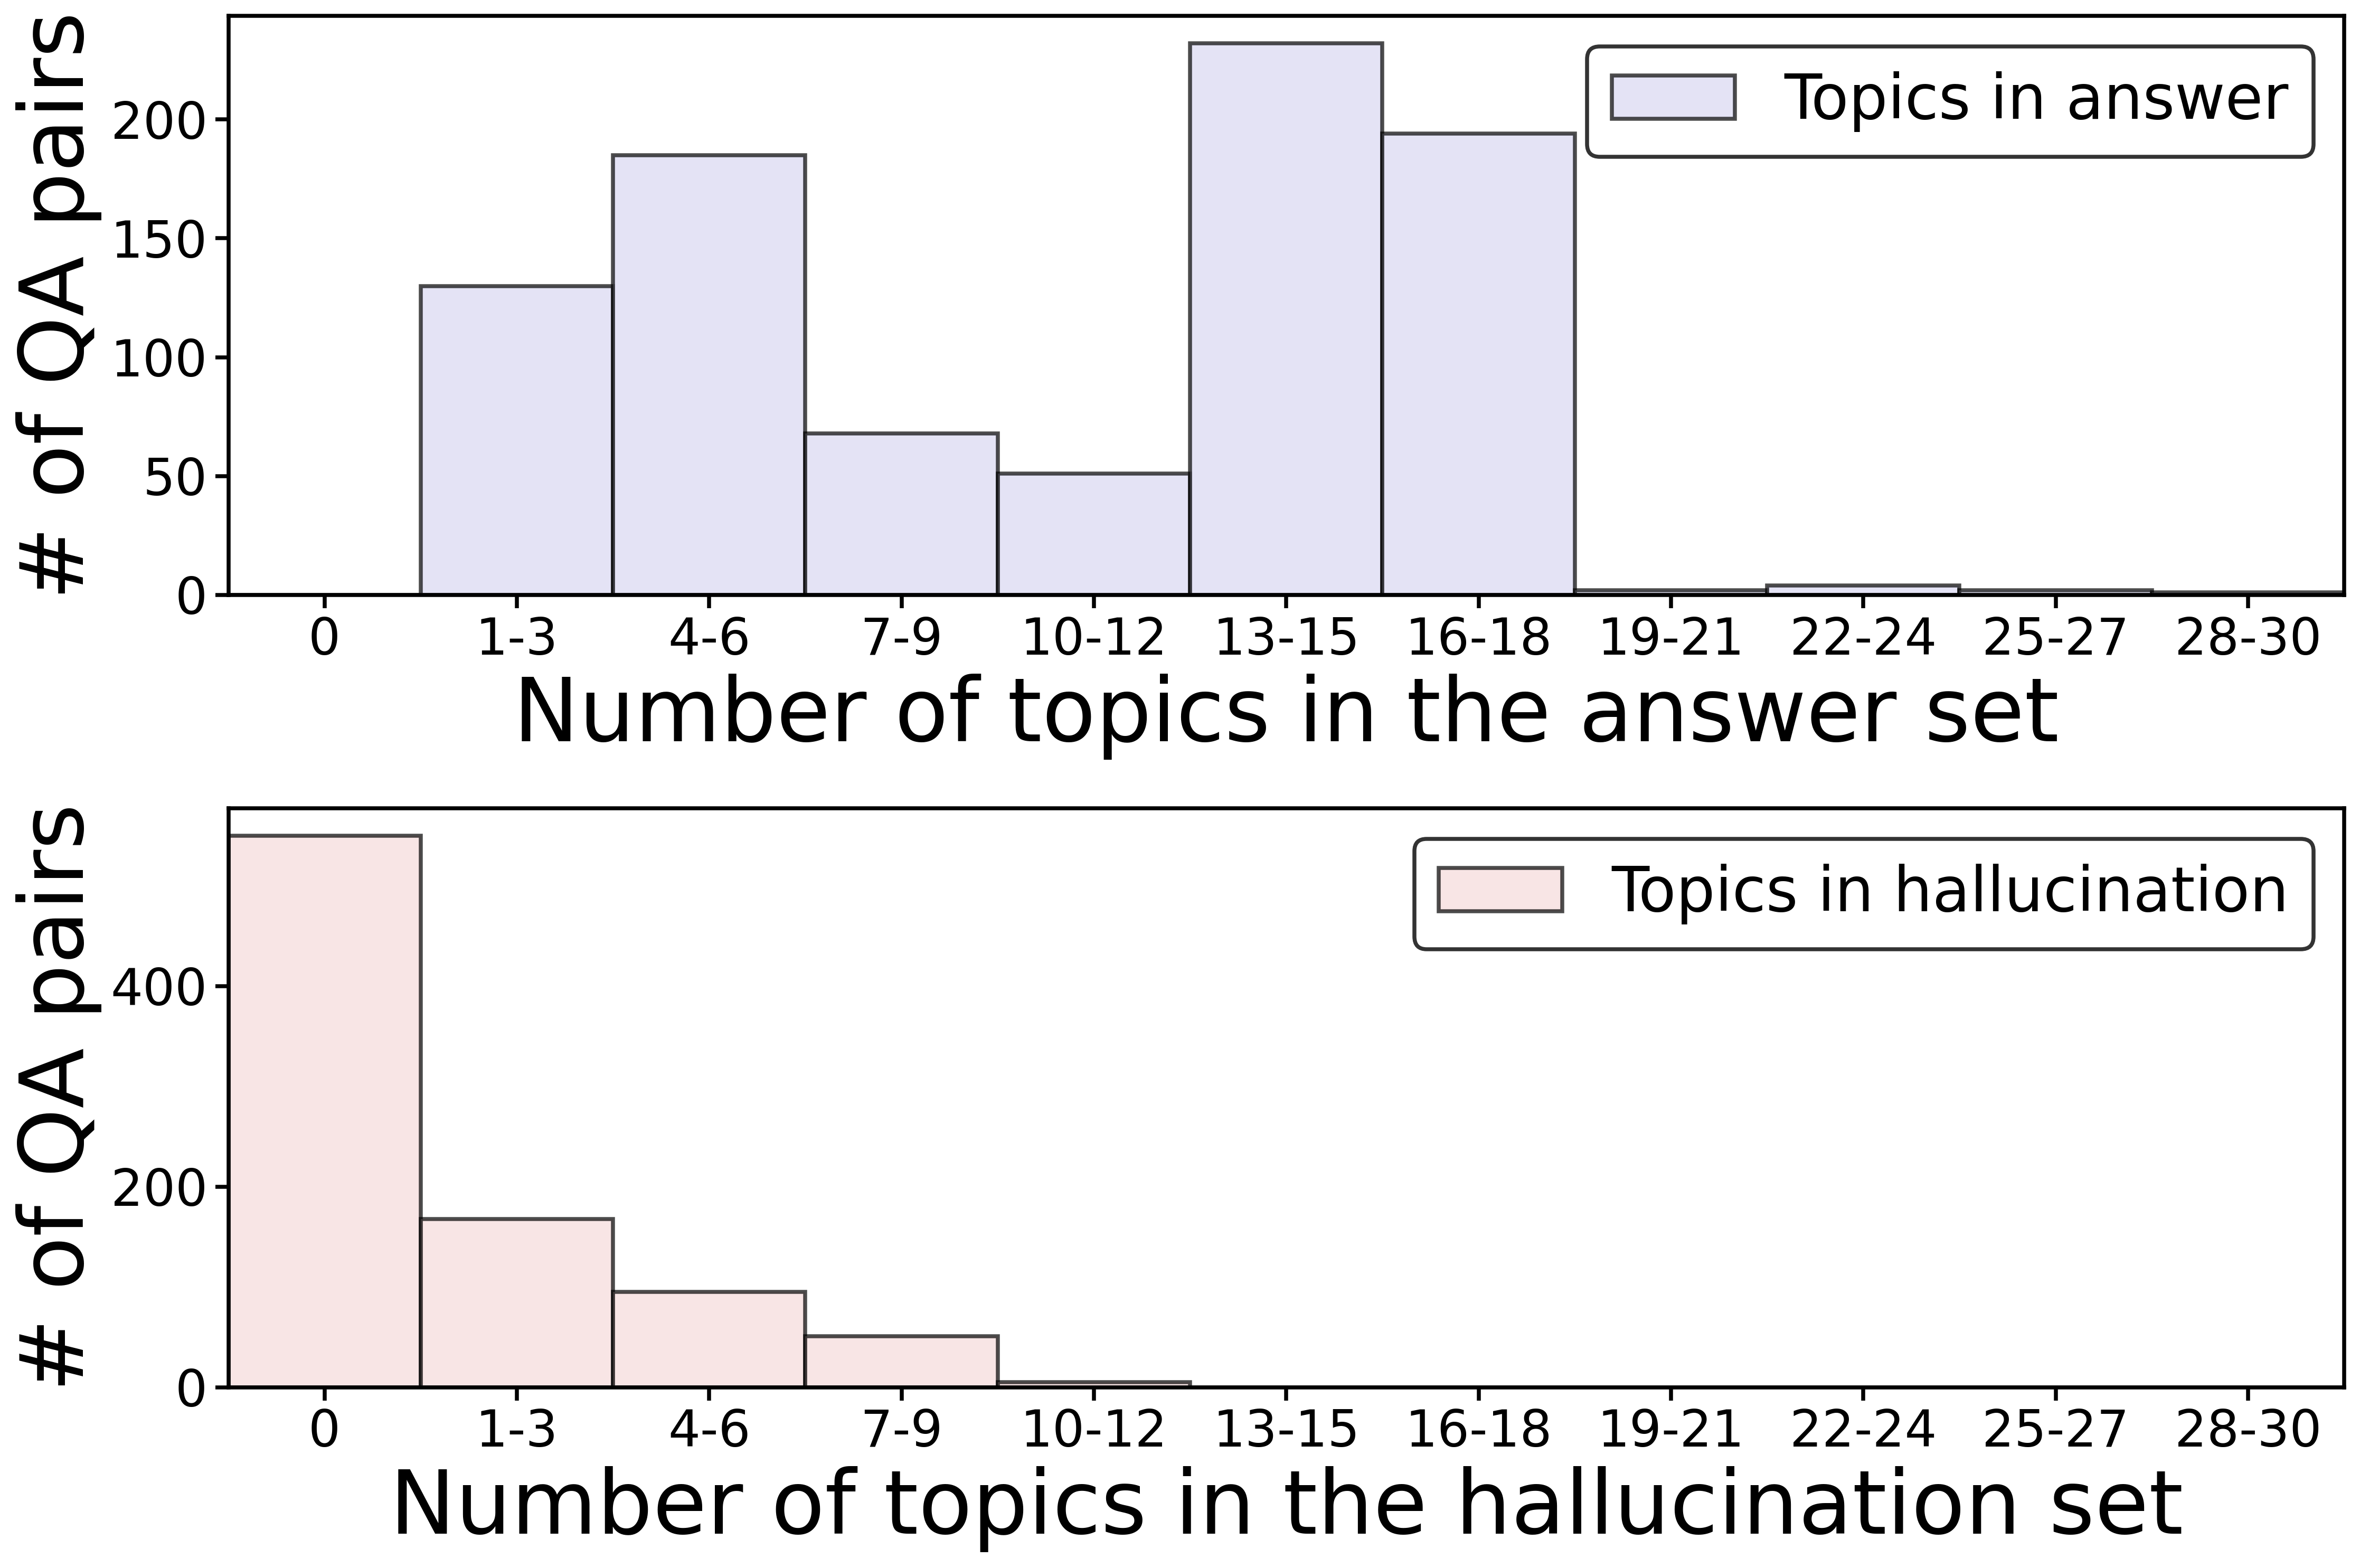

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def get_answer_length(answer):
    if isinstance(answer, list):
        return len(answer)
    if isinstance(answer, str):
        answer = answer.strip()
        if answer == "[]":
            return 0
        if answer.startswith("[") and answer.endswith("]"):
            inner = answer[1:-1].strip()
            if not inner:
                return 0
            return len([item.strip() for item in inner.split(",") if item.strip()])
    raise TypeError(f"Unsupported answer type: {type(answer).__name__}")

def build_group_distribution(lengths, upper_bound=30, zero_count=None, step=2):
    non_zero_lengths = lengths[lengths > 0]
    step = max(int(step), 0)
    length_groups = [(start, min(start + step, upper_bound)) for start in range(1, upper_bound + 1, step + 1)]
    group_labels = ["0"] + [f"{start}-{end}" for start, end in length_groups]
    zero_bucket = int((lengths == 0).sum()) if zero_count is None else int(zero_count)
    group_counts = [zero_bucket] + [non_zero_lengths.between(start, end).sum() if not non_zero_lengths.empty else 0 for start, end in length_groups]
    return group_labels, group_counts


figure_font_size_large = 40
figure_font_size = 23
legend_font_size = 28
def draw_grouped_bar(ax, group_labels, group_counts, xlabel, legend_label, bar_color):
    positions = np.arange(len(group_labels))
    ax.bar(
        positions,
        group_counts,
        color=bar_color,
        edgecolor="black",
        linewidth=1.8,
        alpha=0.7,
        width=1.0,
        label=legend_label,
    )
    ax.set_xlabel(xlabel, fontsize=figure_font_size_large)
    ax.set_ylabel("# of QA pairs", fontsize=figure_font_size_large)
    ax.set_xticks(positions)
    ax.set_xticklabels(group_labels)
    ax.tick_params(axis="both", labelsize=figure_font_size, width=1.8, length=6)
    ax.set_xlim(-0.5, len(group_labels) - 0.5)
    ax.margins(x=0)
    for spine in ax.spines.values():
        spine.set_linewidth(1.8)
    legend = ax.legend(fontsize=legend_font_size)
    legend.get_frame().set_linewidth(1.8)
    legend.get_frame().set_edgecolor("black")

answer_lengths = qa_df_all["answer"].apply(get_answer_length)
com_err_lengths = qa_df_all["com_err"].apply(len)

step = 2

# answer_labels, answer_counts = build_group_distribution(answer_lengths, upper_bound=30, zero_count=0, step=step)
answer_labels, answer_counts = build_group_distribution(answer_lengths, upper_bound=30, step=step)
com_err_labels, com_err_counts = build_group_distribution(com_err_lengths, upper_bound=30, step=step)

output_path = "answer_hall.png"
output_path_pdf = output_path.rsplit(".", 1)[0] + ".pdf"

fig, axes = plt.subplots(2, 1, figsize=(15, 10), dpi=300)
draw_grouped_bar(axes[0], answer_labels, answer_counts, "Number of topics in the answer set", "Topics in answer", "#d9d8f2")
draw_grouped_bar(axes[1], com_err_labels, com_err_counts, "Number of topics in the hallucination set", "Topics in hallucination", "#f6dada")

plt.tight_layout(h_pad=2.2)
fig.savefig(output_path, dpi=300, bbox_inches="tight")
fig.savefig(output_path_pdf, dpi=300, bbox_inches="tight")
plt.show()


In [4]:
zero_answer_rows = qa_df_all.loc[answer_lengths == 0].reset_index(drop=True)
print(f"Number of QA pairs with answer length 0: {len(zero_answer_rows)}")
zero_answer_rows

Number of QA pairs with answer length 0: 0


,question,answer,evidence_list,com_err,reason,titles
